# PHuture 2055
## Can the Philippines sustain its growing population?

This notebook builds a reproducible national-level outlook for **population, electricity, food, and freshwater through 2055**. It retrieves machine-readable data from the United Nations, World Bank, FAOSTAT, and Our World in Data, validates the inputs, compares forecasting models, and evaluates three scenarios.

### Questions answered

1. How could the Philippine population change through 2055?
2. How much electricity demand could that population create?
3. Could electricity generation keep pace under different investment assumptions?
4. Could national dietary energy adequacy remain above 100%?
5. How might renewable freshwater availability per person change?
6. In what year does each scenario first cross a clearly defined screening threshold?

> **Important:** This is a portfolio forecasting exercise, not an official government forecast. A threshold crossing is a national-level warning signal, not a predicted collapse date. National averages can hide regional shortages, infrastructure constraints, inequality, imports, climate shocks, and policy changes.

## Methodology at a glance

| Component | Primary data | Method |
|---|---|---|
| Population | UN World Population Prospects 2024 and World Bank | Official UN medium projection, plus ML trend models for comparison |
| Electricity | OWID harmonized energy dataset, cross-referenced to Philippine DOE | Damped Holt, linear regression, and polynomial ridge backtesting |
| Food | FAOSTAT Food Security Indicators | Forecast of dietary energy supply adequacy |
| Water | World Bank indicators sourced from FAO AQUASTAT | Renewable freshwater and withdrawals scaled by population |
| Uncertainty | Model errors and source disagreement | Monte Carlo simulation |

The final outlook uses the **UN medium population projection** instead of blindly extrapolating an ML curve. Long-range demographic forecasting depends on fertility, mortality, and migration assumptions that a simple time-series model cannot fully represent.

In [1]:
from __future__ import annotations

import base64
import io
import json
import math
import re
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from requests.adapters import HTTPAdapter
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from urllib3.util.retry import Retry

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "navy": "#183B56",
    "blue": "#2F80ED",
    "green": "#27AE60",
    "gold": "#F2C94C",
    "red": "#EB5757",
    "gray": "#7F8C8D",
}

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_END = 2055
WATER_SCREENING_THRESHOLD_M3 = 1_700
ELECTRICITY_COVERAGE_THRESHOLD = 0.90
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Forecast horizon: {FORECAST_END}")

Project root: /workspace/scratch/faa693d3c418/phuture-2055
Forecast horizon: 2055


## 1. Reproducible data collection

Every network response is cached under `data/raw/`. Delete a cached file to force a fresh download. The notebook records the retrieval time and source URL in `outputs/source_manifest.csv`.

The pipeline prefers APIs and bulk downloads over fragile HTML scraping. The OWID loader includes a GitHub API fallback when the raw-file endpoint is rate-limited.

In [2]:
UN_WPP_URL = (
    "https://population.un.org/wpp/assets/Excel%20Files/"
    "1_Indicator%20(Standard)/CSV_FILES/"
    "WPP2024_Demographic_Indicators_Medium.csv.gz"
)
FAOSTAT_INDEX_URL = "https://bulks-faostat.fao.org/production/datasets_E.json"
WORLD_BANK_TEMPLATE = (
    "https://api.worldbank.org/v2/country/PHL/indicator/{indicator}"
    "?format=json&per_page=100"
)
OWID_RAW_URL = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
OWID_CONTENTS_API = "https://api.github.com/repos/owid/energy-data/contents/owid-energy-data.csv?ref=master"

session = requests.Session()
retry = Retry(
    total=4,
    backoff_factor=1.0,
    status_forcelist=(429, 500, 502, 503, 504),
    allowed_methods=("GET",),
)
session.mount("https://", HTTPAdapter(max_retries=retry))
session.headers.update({"User-Agent": "PHuture-2055/1.0 educational-data-project"})

source_records: list[dict] = []


def record_source(name: str, url: str, local_path: Path, latest_year=None) -> None:
    source_records.append(
        {
            "source": name,
            "url": url,
            "cached_file": str(local_path.relative_to(PROJECT_ROOT)),
            "retrieved_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
            "latest_data_year": latest_year,
        }
    )


def cached_download(url: str, destination: Path, timeout: int = 120) -> Path:
    if destination.exists() and destination.stat().st_size > 0:
        return destination
    response = session.get(url, timeout=timeout)
    response.raise_for_status()
    temporary = destination.with_suffix(destination.suffix + ".part")
    temporary.write_bytes(response.content)
    temporary.replace(destination)
    return destination


def load_world_bank_indicator(indicator: str, label: str) -> pd.DataFrame:
    destination = DATA_DIR / f"world_bank_{indicator.replace('.', '_')}.csv"
    url = WORLD_BANK_TEMPLATE.format(indicator=indicator)
    if destination.exists() and destination.stat().st_size > 0:
        frame = pd.read_csv(destination)
    else:
        response = session.get(url, timeout=60)
        response.raise_for_status()
        payload = response.json()
        if len(payload) < 2 or payload[1] is None:
            raise ValueError(f"World Bank returned no observations for {indicator}")
        frame = pd.DataFrame(
            [
                {"year": int(row["date"]), "value": row["value"]}
                for row in payload[1]
                if row["value"] is not None
            ]
        ).sort_values("year")
        frame.to_csv(destination, index=False)
    frame["year"] = frame["year"].astype(int)
    frame["value"] = pd.to_numeric(frame["value"], errors="coerce")
    frame = frame.dropna().drop_duplicates("year").sort_values("year")
    record_source(label, url, destination, int(frame["year"].max()))
    return frame


def load_un_population() -> pd.DataFrame:
    destination = DATA_DIR / "WPP2024_Demographic_Indicators_Medium.csv.gz"
    cached_download(UN_WPP_URL, destination, timeout=180)
    frame = pd.read_csv(
        destination,
        usecols=["ISO3_code", "Location", "Variant", "Time", "TPopulation1July"],
        low_memory=False,
    )
    frame = frame.loc[frame["ISO3_code"].eq("PHL"), ["Time", "TPopulation1July"]]
    frame = frame.rename(columns={"Time": "year", "TPopulation1July": "population_thousands"})
    frame["population_millions"] = frame["population_thousands"] / 1_000
    frame = frame.query("1950 <= year <= @FORECAST_END").drop_duplicates("year").sort_values("year")
    record_source("UN World Population Prospects 2024", UN_WPP_URL, destination, int(frame["year"].max()))
    return frame


def load_faostat_food_security() -> pd.DataFrame:
    index_response = session.get(FAOSTAT_INDEX_URL, timeout=60)
    index_response.raise_for_status()
    datasets = index_response.json()["Datasets"]["Dataset"]
    metadata = next(item for item in datasets if item["DatasetCode"] == "FS")
    url = metadata["FileLocation"]
    destination = DATA_DIR / "faostat_food_security.zip"
    cached_download(url, destination, timeout=180)
    with zipfile.ZipFile(destination) as archive:
        data_name = next(
            name for name in archive.namelist()
            if "All_Data_(Normalized).csv" in name
        )
        frame = pd.read_csv(archive.open(data_name), encoding="latin-1", low_memory=False)
    target_item = "Average dietary energy supply adequacy (percent) (3-year average)"
    frame = frame.loc[
        frame["Area"].eq("Philippines") & frame["Item"].eq(target_item),
        ["Year", "Value", "Unit", "Flag"],
    ].copy()

    def midpoint(year_label: str) -> int:
        years = [int(value) for value in re.findall(r"\d{4}", str(year_label))]
        return int(round(sum(years) / len(years)))

    frame["year"] = frame["Year"].map(midpoint)
    frame["food_adequacy_pct"] = pd.to_numeric(
        frame["Value"].astype(str).str.replace(r"[<>]", "", regex=True),
        errors="coerce",
    )
    frame = frame[["year", "food_adequacy_pct"]].dropna().drop_duplicates("year").sort_values("year")
    record_source("FAOSTAT Food Security Indicators", url, destination, int(frame["year"].max()))
    return frame


def download_owid_energy(destination: Path) -> Path:
    try:
        return cached_download(OWID_RAW_URL, destination, timeout=180)
    except requests.RequestException:
        metadata_response = session.get(OWID_CONTENTS_API, timeout=60)
        metadata_response.raise_for_status()
        blob_url = metadata_response.json()["git_url"]
        blob_response = session.get(blob_url, timeout=180)
        blob_response.raise_for_status()
        content = base64.b64decode(blob_response.json()["content"])
        destination.write_bytes(content)
        return destination


def load_owid_energy() -> pd.DataFrame:
    destination = DATA_DIR / "owid-energy-data.csv"
    download_owid_energy(destination)
    columns = [
        "country",
        "year",
        "population",
        "electricity_demand",
        "electricity_generation",
        "electricity_demand_per_capita",
    ]
    frame = pd.read_csv(destination, usecols=columns)
    frame = frame.loc[frame["country"].eq("Philippines")].copy()
    frame = frame.rename(
        columns={
            "electricity_demand": "electricity_demand_twh",
            "electricity_generation": "electricity_generation_twh",
            "electricity_demand_per_capita": "electricity_demand_per_capita_kwh",
        }
    )
    frame = frame.dropna(subset=["electricity_generation_twh", "electricity_demand_per_capita_kwh"])
    frame = frame.sort_values("year")
    record_source("Our World in Data Energy Dataset", OWID_RAW_URL, destination, int(frame["year"].max()))
    return frame

In [3]:
# Load all sources. Network downloads are cached after the first successful run.
un_population = load_un_population()
wb_population = load_world_bank_indicator("SP.POP.TOTL", "World Bank population")
wb_population["population_millions"] = wb_population["value"] / 1_000_000

wb_renewable_water = load_world_bank_indicator(
    "ER.H2O.INTR.K3", "World Bank / FAO AQUASTAT renewable freshwater"
)
wb_water_withdrawal = load_world_bank_indicator(
    "ER.H2O.FWTL.K3", "World Bank / FAO AQUASTAT freshwater withdrawals"
)
wb_water_stress = load_world_bank_indicator(
    "ER.H2O.FWST.ZS", "World Bank / FAO AQUASTAT water stress"
)

food = load_faostat_food_security()
energy = load_owid_energy()

source_manifest = pd.DataFrame(source_records).drop_duplicates("source", keep="last")
source_manifest.to_csv(OUTPUT_DIR / "source_manifest.csv", index=False)

summary = pd.DataFrame(
    {
        "dataset": ["UN population", "World Bank population", "Electricity", "Food", "Water"],
        "first_year": [
            un_population.year.min(), wb_population.year.min(), energy.year.min(),
            food.year.min(), wb_renewable_water.year.min(),
        ],
        "latest_year": [
            un_population.year.max(), wb_population.year.max(), energy.year.max(),
            food.year.max(), wb_renewable_water.year.max(),
        ],
        "observations": [
            len(un_population), len(wb_population), len(energy), len(food), len(wb_renewable_water),
        ],
    }
)
display(summary)
display(source_manifest[["source", "latest_data_year", "cached_file"]])

,dataset,first_year,latest_year,observations
0,UN population,1950,2055,106
1,World Bank population,1960,2025,66
2,Electricity,2000,2025,26
3,Food,2001,2024,24
4,Water,1961,2022,62


,source,latest_data_year,cached_file
0,UN World Population Prospects 2024,2055,data/raw/WPP2024_Demographic_Indicators_Medium.csv.gz
1,World Bank population,2025,data/raw/world_bank_SP_POP_TOTL.csv
2,World Bank / FAO AQUASTAT renewable freshwater,2022,data/raw/world_bank_ER_H2O_INTR_K3.csv
3,World Bank / FAO AQUASTAT freshwater withdrawals,2022,data/raw/world_bank_ER_H2O_FWTL_K3.csv
4,World Bank / FAO AQUASTAT water stress,2022,data/raw/world_bank_ER_H2O_FWST_ZS.csv
5,FAOSTAT Food Security Indicators,2024,data/raw/faostat_food_security.zip
6,Our World in Data Energy Dataset,2025,data/raw/owid-energy-data.csv


## 2. Data quality checks

These assertions stop the notebook if a source unexpectedly changes, required fields disappear, years are duplicated, or values fall outside basic physical ranges.

In [4]:
def assert_annual_series(frame: pd.DataFrame, year_col: str, value_col: str, minimum: float = 0) -> None:
    assert not frame.empty, f"{value_col} is empty"
    assert frame[year_col].is_unique, f"Duplicate years found in {value_col}"
    assert frame[value_col].notna().all(), f"Missing values found in {value_col}"
    assert (frame[value_col] >= minimum).all(), f"Unexpected negative values in {value_col}"


assert_annual_series(un_population, "year", "population_millions")
assert_annual_series(wb_population, "year", "population_millions")
assert_annual_series(food, "year", "food_adequacy_pct")
assert_annual_series(energy, "year", "electricity_generation_twh")
assert wb_population["year"].max() >= 2020
assert energy["year"].max() >= 2020
assert food["year"].max() >= 2020
assert un_population.query("year == 2055")["population_millions"].notna().all()

print("All data quality checks passed.")

All data quality checks passed.


## 3. Population outlook

Three trend models are backtested on World Bank historical observations. Their role is educational: they demonstrate model comparison and expose the danger of long-range extrapolation. The scenario engine uses the UN demographic projection as its population baseline.

The Philippine Statistics Authority's 2020 census-based **Scenario 2** projects **138.67 million people in 2055**. That figure is shown as an external benchmark and is not used to train the models.

In [5]:
def annual_series(frame: pd.DataFrame, year_col: str, value_col: str, start_year=None) -> pd.Series:
    clean = frame[[year_col, value_col]].dropna().drop_duplicates(year_col).sort_values(year_col)
    if start_year is not None:
        clean = clean.loc[clean[year_col] >= start_year]
    series = clean.set_index(year_col)[value_col].astype(float)
    full_index = pd.Index(range(int(series.index.min()), int(series.index.max()) + 1), name="year")
    return series.reindex(full_index).interpolate(limit_direction="both")


def _predict_model(model_name: str, train: pd.Series, prediction_years: np.ndarray) -> np.ndarray:
    x_train = train.index.to_numpy().reshape(-1, 1)
    y_train = train.to_numpy()
    x_pred = np.asarray(prediction_years).reshape(-1, 1)
    if model_name == "Linear regression":
        model = LinearRegression().fit(x_train, y_train)
        return model.predict(x_pred)
    if model_name == "Polynomial ridge":
        model = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=10.0))
        model.fit(x_train, y_train)
        return model.predict(x_pred)
    if model_name == "Damped Holt":
        fitted = ExponentialSmoothing(
            y_train,
            trend="add",
            damped_trend=True,
            seasonal=None,
            initialization_method="estimated",
        ).fit(optimized=True)
        first_future_year = int(train.index.max()) + 1
        steps = int(np.max(prediction_years) - train.index.max())
        forecast = fitted.forecast(steps)
        lookup = dict(zip(range(first_future_year, first_future_year + steps), forecast))
        return np.array([lookup[int(year)] for year in prediction_years])
    raise ValueError(f"Unknown model: {model_name}")


def compare_and_forecast(series: pd.Series, future_years: np.ndarray, label: str):
    models = ["Linear regression", "Polynomial ridge", "Damped Holt"]
    holdout = min(5, max(3, len(series) // 5))
    train, test = series.iloc[:-holdout], series.iloc[-holdout:]
    rows = []
    validation_predictions = {}
    for model_name in models:
        predicted = _predict_model(model_name, train, test.index.to_numpy())
        validation_predictions[model_name] = predicted
        rows.append(
            {
                "series": label,
                "model": model_name,
                "MAE": mean_absolute_error(test, predicted),
                "RMSE": math.sqrt(mean_squared_error(test, predicted)),
                "MAPE_pct": 100 * mean_absolute_percentage_error(test, predicted),
            }
        )
    scores = pd.DataFrame(rows).sort_values(["MAPE_pct", "RMSE"])
    best_model = scores.iloc[0]["model"]
    forecast = _predict_model(best_model, series, future_years)
    forecast = pd.Series(np.maximum(forecast, 0), index=future_years, name=label)
    return scores, best_model, forecast


population_history = annual_series(wb_population, "year", "population_millions", start_year=1960)
population_future_years = np.arange(int(population_history.index.max()) + 1, FORECAST_END + 1)
population_scores, population_best, population_ml = compare_and_forecast(
    population_history, population_future_years, "Population (millions)"
)

un_projection = (
    un_population.query("year >= @population_future_years.min()")
    .set_index("year")["population_millions"]
    .reindex(population_future_years)
    .interpolate()
)
psa_2055_millions = 138.67

display(population_scores)
print(f"Best historical holdout model: {population_best}")
print(f"UN medium projection for 2055: {un_projection.loc[2055]:.2f} million")
print(f"PSA Scenario 2 benchmark for 2055: {psa_2055_millions:.2f} million")

Best historical holdout model: Polynomial ridge
UN medium projection for 2055: 135.14 million
PSA Scenario 2 benchmark for 2055: 138.67 million


,series,model,MAE,RMSE,MAPE_pct
1,Population (millions),Polynomial ridge,0.778,0.940,0.681
2,Population (millions),Damped Holt,0.949,1.058,0.821
0,Population (millions),Linear regression,0.999,1.226,0.876


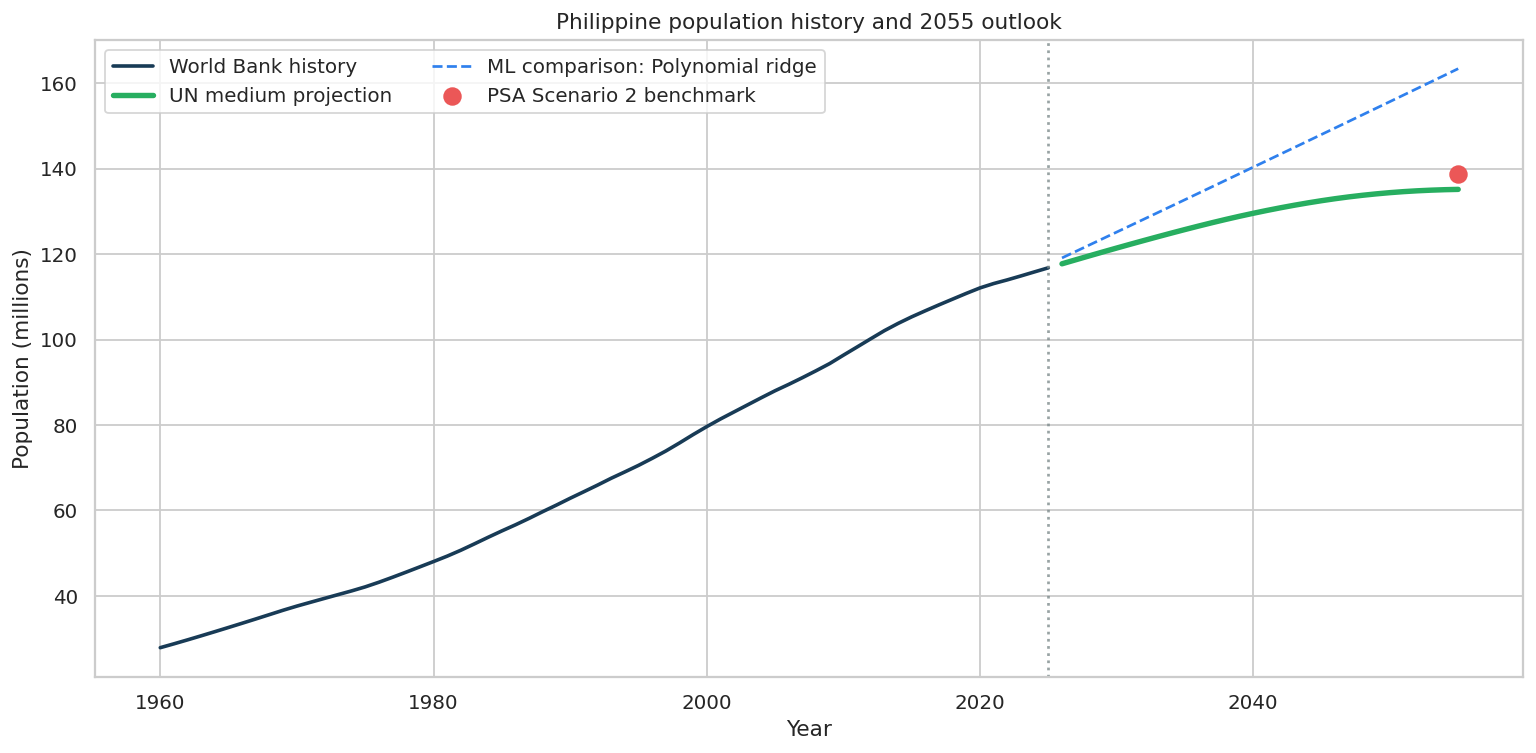

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(population_history.index, population_history.values, color=COLORS["navy"], linewidth=2, label="World Bank history")
ax.plot(un_projection.index, un_projection.values, color=COLORS["green"], linewidth=3, label="UN medium projection")
ax.plot(population_ml.index, population_ml.values, color=COLORS["blue"], linestyle="--", label=f"ML comparison: {population_best}")
ax.scatter([2055], [psa_2055_millions], color=COLORS["red"], s=85, zorder=5, label="PSA Scenario 2 benchmark")
ax.axvline(population_history.index.max(), color=COLORS["gray"], linestyle=":", alpha=0.8)
ax.set(title="Philippine population history and 2055 outlook", xlabel="Year", ylabel="Population (millions)")
ax.legend(frameon=True, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "population_forecast.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Resource forecasting models

Each resource series is backtested using the same final-year holdout. The selected model is the one with the lowest validation MAPE, with RMSE as the tie-breaker.

- **Electricity demand** is population multiplied by forecast per-capita electricity demand.
- **Electricity supply** is represented by forecast electricity generation.
- **Material electricity pressure** is screened when modeled annual generation falls below 90% of modeled annual demand. The 90% line is a transparent portfolio assumption, not an official reliability standard.
- **Food adequacy** is FAOSTAT's dietary energy supply adequacy. Values at or above 100% indicate aggregate dietary energy supply meets estimated requirements, but do not prove equal access.
- **Freshwater availability** divides renewable internal freshwater by population. The configurable 1,700 m³/person/year line is used only as a national screening benchmark.

In [7]:
energy_history = energy.query("year >= 1990").copy()
generation_series = annual_series(energy_history, "year", "electricity_generation_twh")
electricity_pc_series = annual_series(
    energy_history, "year", "electricity_demand_per_capita_kwh"
)
food_series = annual_series(food, "year", "food_adequacy_pct")

last_energy_year = int(min(generation_series.index.max(), electricity_pc_series.index.max()))
resource_years = np.arange(last_energy_year + 1, FORECAST_END + 1)

generation_scores, generation_best, generation_forecast = compare_and_forecast(
    generation_series, resource_years, "Electricity generation (TWh)"
)
electricity_pc_scores, electricity_pc_best, electricity_pc_forecast = compare_and_forecast(
    electricity_pc_series, resource_years, "Electricity demand per capita (kWh)"
)

food_future_years = np.arange(int(food_series.index.max()) + 1, FORECAST_END + 1)
food_scores, food_best, food_forecast_raw = compare_and_forecast(
    food_series, food_future_years, "Food adequacy (%)"
)

# Calibrate the first projected value to the latest observed level to avoid a visual jump.
def calibrate_forecast(forecast: pd.Series, latest_value: float) -> pd.Series:
    if forecast.empty or forecast.iloc[0] == 0:
        return forecast
    return forecast * (latest_value / forecast.iloc[0])


generation_forecast = calibrate_forecast(generation_forecast, generation_series.iloc[-1])
electricity_pc_forecast = calibrate_forecast(electricity_pc_forecast, electricity_pc_series.iloc[-1])
food_forecast_raw = calibrate_forecast(food_forecast_raw, food_series.iloc[-1])

model_validation = pd.concat(
    [population_scores, generation_scores, electricity_pc_scores, food_scores],
    ignore_index=True,
)
model_validation["selected"] = model_validation.apply(
    lambda row: row["model"] == {
        "Population (millions)": population_best,
        "Electricity generation (TWh)": generation_best,
        "Electricity demand per capita (kWh)": electricity_pc_best,
        "Food adequacy (%)": food_best,
    }[row["series"]],
    axis=1,
)
model_validation.to_csv(OUTPUT_DIR / "model_validation.csv", index=False)

display(model_validation.sort_values(["series", "MAPE_pct"]))

,series,model,MAE,RMSE,MAPE_pct,selected
6,Electricity demand per capita (kWh),Damped Holt,50.218,58.221,4.838,True
7,Electricity demand per capita (kWh),Polynomial ridge,53.826,60.205,5.210,False
8,Electricity demand per capita (kWh),Linear regression,54.516,60.882,5.277,False
3,Electricity generation (TWh),Damped Holt,6.590,7.477,5.510,True
4,Electricity generation (TWh),Polynomial ridge,6.825,7.499,5.740,False
5,Electricity generation (TWh),Linear regression,6.936,7.609,5.834,False
9,Food adequacy (%),Damped Holt,0.913,1.034,0.713,True
10,Food adequacy (%),Polynomial ridge,6.183,6.222,4.853,False
11,Food adequacy (%),Linear regression,6.211,6.251,4.876,False
0,Population (millions),Polynomial ridge,0.778,0.940,0.681,True


## 5. Scenario engine

The scenarios deliberately expose their annual adjustments. These are **assumptions**, not hidden model facts. Change them below and rerun the remaining cells.

| Scenario | Interpretation |
|---|---|
| Baseline | Selected model trends continue |
| Infrastructure lag | Supply investment slows while demand and climate pressure rise |
| Investment and efficiency | Capacity, productivity, conservation, and efficiency improve |

In [8]:
SCENARIOS = {
    "Baseline": {
        "energy_supply_delta": 0.000,
        "energy_demand_pc_delta": 0.000,
        "food_delta": 0.000,
        "water_use_pc_delta": 0.000,
        "effective_water_delta": 0.000,
    },
    "Infrastructure lag": {
        "energy_supply_delta": -0.008,
        "energy_demand_pc_delta": 0.004,
        "food_delta": -0.006,
        "water_use_pc_delta": 0.004,
        "effective_water_delta": -0.003,
    },
    "Investment and efficiency": {
        "energy_supply_delta": 0.012,
        "energy_demand_pc_delta": -0.004,
        "food_delta": 0.004,
        "water_use_pc_delta": -0.006,
        "effective_water_delta": 0.002,
    },
}


def latest_value(frame: pd.DataFrame) -> tuple[int, float]:
    row = frame.sort_values("year").iloc[-1]
    return int(row["year"]), float(row["value"])


renewable_year, renewable_water_km3 = latest_value(wb_renewable_water)
withdrawal_year, freshwater_withdrawal_km3 = latest_value(wb_water_withdrawal)
water_stress_year, reported_water_stress_pct = latest_value(wb_water_stress)

latest_population_for_water = float(
    un_population.set_index("year")["population_millions"].reindex([withdrawal_year], method="nearest").iloc[0]
)
withdrawal_per_capita_m3 = freshwater_withdrawal_km3 * 1_000 / latest_population_for_water

# Put all baseline forecasts on a common annual index.
years = np.arange(max(last_energy_year + 1, 2026), FORECAST_END + 1)
population_baseline = un_population.set_index("year")["population_millions"].reindex(years).interpolate()
generation_base = generation_forecast.reindex(years).interpolate(limit_direction="both")
electricity_pc_base = electricity_pc_forecast.reindex(years).interpolate(limit_direction="both")
food_base = food_forecast_raw.reindex(years).interpolate(limit_direction="both")

scenario_frames = []
for scenario_name, assumptions in SCENARIOS.items():
    years_ahead = years - years.min() + 1
    energy_supply = generation_base.values * (1 + assumptions["energy_supply_delta"]) ** years_ahead
    energy_demand_pc = electricity_pc_base.values * (1 + assumptions["energy_demand_pc_delta"]) ** years_ahead
    energy_demand = energy_demand_pc * population_baseline.values / 1_000
    food_adequacy = food_base.values * (1 + assumptions["food_delta"]) ** years_ahead
    effective_water = renewable_water_km3 * (1 + assumptions["effective_water_delta"]) ** years_ahead
    water_use_pc = withdrawal_per_capita_m3 * (1 + assumptions["water_use_pc_delta"]) ** years_ahead
    water_withdrawal = water_use_pc * population_baseline.values / 1_000
    water_per_capita = effective_water * 1_000 / population_baseline.values

    scenario_frames.append(
        pd.DataFrame(
            {
                "scenario": scenario_name,
                "year": years,
                "population_millions": population_baseline.values,
                "electricity_supply_twh": energy_supply,
                "electricity_demand_twh": energy_demand,
                "electricity_coverage_ratio": energy_supply / energy_demand,
                "food_adequacy_pct": food_adequacy,
                "effective_renewable_water_km3": effective_water,
                "freshwater_withdrawal_km3": water_withdrawal,
                "renewable_water_per_capita_m3": water_per_capita,
                "withdrawal_share_pct": 100 * water_withdrawal / effective_water,
            }
        )
    )

forecast_long = pd.concat(scenario_frames, ignore_index=True)
forecast_long.to_csv(OUTPUT_DIR / "forecast_long.csv", index=False)
forecast_long.head()

In [9]:
def first_breach(frame: pd.DataFrame, column: str, threshold: float, direction: str) -> str:
    if direction == "below":
        breached = frame.loc[frame[column] < threshold, "year"]
    else:
        breached = frame.loc[frame[column] > threshold, "year"]
    return str(int(breached.iloc[0])) if not breached.empty else f">{FORECAST_END}"


outlook_rows = []
for scenario_name, frame in forecast_long.groupby("scenario", sort=False):
    row_2055 = frame.loc[frame["year"].eq(FORECAST_END)].iloc[0]
    outlook_rows.append(
        {
            "scenario": scenario_name,
            "population_2055_millions": row_2055["population_millions"],
            "electricity_coverage_2055_pct": 100 * row_2055["electricity_coverage_ratio"],
            "first_electricity_below_90_year": first_breach(
                frame, "electricity_coverage_ratio", ELECTRICITY_COVERAGE_THRESHOLD, "below"
            ),
            "food_adequacy_2055_pct": row_2055["food_adequacy_pct"],
            "first_food_below_100_year": first_breach(frame, "food_adequacy_pct", 100, "below"),
            "renewable_water_2055_m3_per_person": row_2055["renewable_water_per_capita_m3"],
            "first_water_below_1700_year": first_breach(
                frame, "renewable_water_per_capita_m3", WATER_SCREENING_THRESHOLD_M3, "below"
            ),
            "freshwater_withdrawal_share_2055_pct": row_2055["withdrawal_share_pct"],
        }
    )

scenario_outlook = pd.DataFrame(outlook_rows)
scenario_outlook.to_csv(OUTPUT_DIR / "scenario_outlook.csv", index=False)
display(scenario_outlook)

print(
    f"Latest water inputs: {renewable_water_km3:.1f} km³ renewable water "
    f"({renewable_year}) and {freshwater_withdrawal_km3:.1f} km³ withdrawals "
    f"({withdrawal_year}). Reported water stress was {reported_water_stress_pct:.1f}% "
    f"in {water_stress_year}."
)

Latest water inputs: 479.0 km³ renewable water (2022) and 91.0 km³ withdrawals (2022). Reported water stress was 27.8% in 2022.


,scenario,population_2055_millions,electricity_coverage_2055_pct,first_electricity_below_90_year,food_adequacy_2055_pct,first_food_below_100_year,renewable_water_2055_m3_per_person,first_water_below_1700_year,freshwater_withdrawal_share_2055_pct
0,Baseline,135.139,96.137,>2055,136.557,>2055,"3,544.495",>2055,22.537
1,Infrastructure lag,135.139,67.024,2032,114.000,>2055,"3,238.987",>2055,27.800
2,Investment and efficiency,135.139,155.069,>2055,153.930,>2055,"3,763.449",>2055,17.720


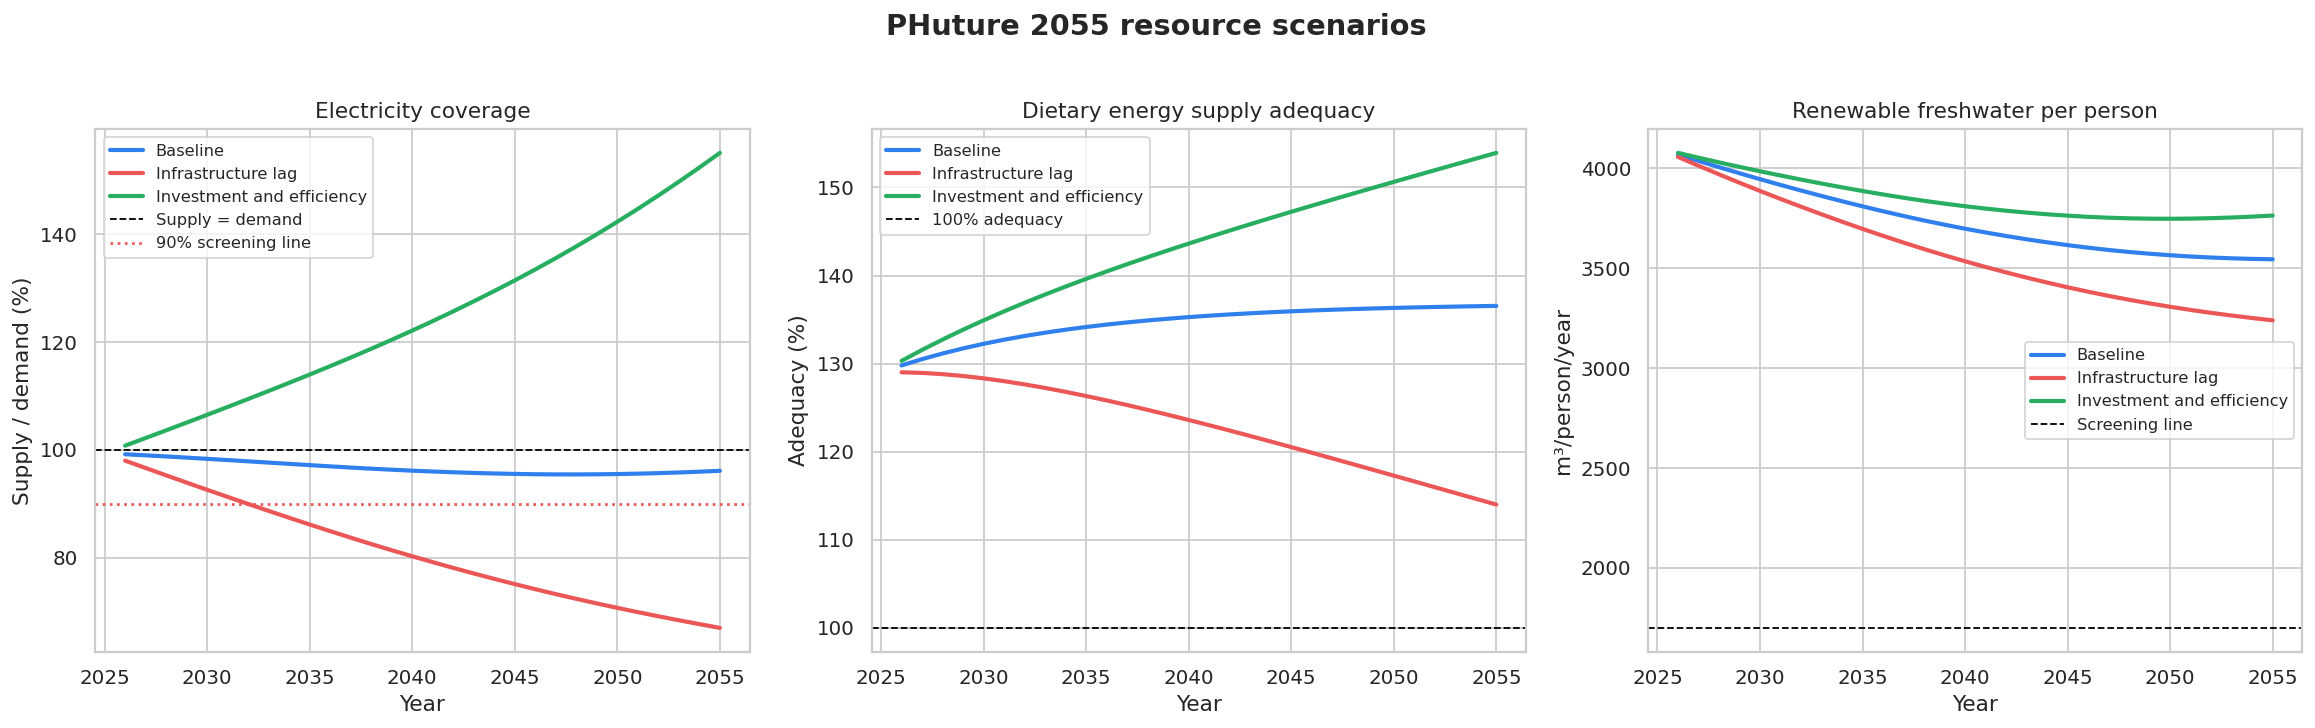

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
palette = {
    "Baseline": COLORS["blue"],
    "Infrastructure lag": COLORS["red"],
    "Investment and efficiency": COLORS["green"],
}

for scenario_name, frame in forecast_long.groupby("scenario", sort=False):
    axes[0].plot(frame.year, 100 * frame.electricity_coverage_ratio, label=scenario_name, color=palette[scenario_name], linewidth=2.3)
    axes[1].plot(frame.year, frame.food_adequacy_pct, label=scenario_name, color=palette[scenario_name], linewidth=2.3)
    axes[2].plot(frame.year, frame.renewable_water_per_capita_m3, label=scenario_name, color=palette[scenario_name], linewidth=2.3)

axes[0].axhline(100, color="black", linestyle="--", linewidth=1, label="Supply = demand")
axes[0].axhline(100 * ELECTRICITY_COVERAGE_THRESHOLD, color=COLORS["red"], linestyle=":", linewidth=1.5, label="90% screening line")
axes[1].axhline(100, color="black", linestyle="--", linewidth=1, label="100% adequacy")
axes[2].axhline(WATER_SCREENING_THRESHOLD_M3, color="black", linestyle="--", linewidth=1, label="Screening line")

axes[0].set(title="Electricity coverage", xlabel="Year", ylabel="Supply / demand (%)")
axes[1].set(title="Dietary energy supply adequacy", xlabel="Year", ylabel="Adequacy (%)")
axes[2].set(title="Renewable freshwater per person", xlabel="Year", ylabel="m³/person/year")
axes[0].legend(fontsize=9)
for ax in axes[1:]:
    ax.legend(fontsize=9)
fig.suptitle("PHuture 2055 resource scenarios", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "resource_scenarios.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Monte Carlo uncertainty

The deterministic scenarios are useful for comparison, but they can look more certain than they are. This simulation perturbs the 2055 baseline using historical holdout errors and the difference between the UN and PSA population projections.

The resulting percentages are **model-based risk frequencies**, not actuarial probabilities.

In [11]:
n_simulations = 5_000
rng = np.random.default_rng(RANDOM_SEED)
baseline_2055 = forecast_long.query("scenario == 'Baseline' and year == @FORECAST_END").iloc[0]

population_sigma = max(abs(psa_2055_millions - baseline_2055.population_millions) / 1.96, 1.0)
generation_mape = generation_scores.iloc[0].MAPE_pct / 100
electricity_pc_mape = electricity_pc_scores.iloc[0].MAPE_pct / 100
food_rmse = food_scores.iloc[0].RMSE

population_draw = rng.normal(baseline_2055.population_millions, population_sigma, n_simulations)
energy_supply_draw = baseline_2055.electricity_supply_twh * rng.lognormal(
    mean=0, sigma=max(generation_mape, 0.03), size=n_simulations
)
electricity_pc_2055 = (
    baseline_2055.electricity_demand_twh * 1_000 / baseline_2055.population_millions
)
energy_pc_draw = electricity_pc_2055 * rng.lognormal(
    mean=0, sigma=max(electricity_pc_mape, 0.03), size=n_simulations
)
energy_demand_draw = energy_pc_draw * population_draw / 1_000
food_draw = rng.normal(baseline_2055.food_adequacy_pct, max(food_rmse, 2.0), n_simulations)
renewable_water_draw = renewable_water_km3 * rng.lognormal(mean=0, sigma=0.05, size=n_simulations)
water_per_capita_draw = renewable_water_draw * 1_000 / population_draw

risk_probability = pd.DataFrame(
    {
        "screening_event": [
            "Electricity supply below 90% of modeled demand",
            "Food adequacy below 100%",
            f"Renewable water below {WATER_SCREENING_THRESHOLD_M3:,} m³/person",
        ],
        "frequency_pct": [
            100 * np.mean(energy_supply_draw < ELECTRICITY_COVERAGE_THRESHOLD * energy_demand_draw),
            100 * np.mean(food_draw < 100),
            100 * np.mean(water_per_capita_draw < WATER_SCREENING_THRESHOLD_M3),
        ],
    }
)
risk_probability.to_csv(OUTPUT_DIR / "monte_carlo_risk.csv", index=False)
display(risk_probability)

,screening_event,frequency_pct
0,Electricity supply below 90% of modeled demand,18.760
1,Food adequacy below 100%,0.000
2,"Renewable water below 1,700 m³/person",0.000


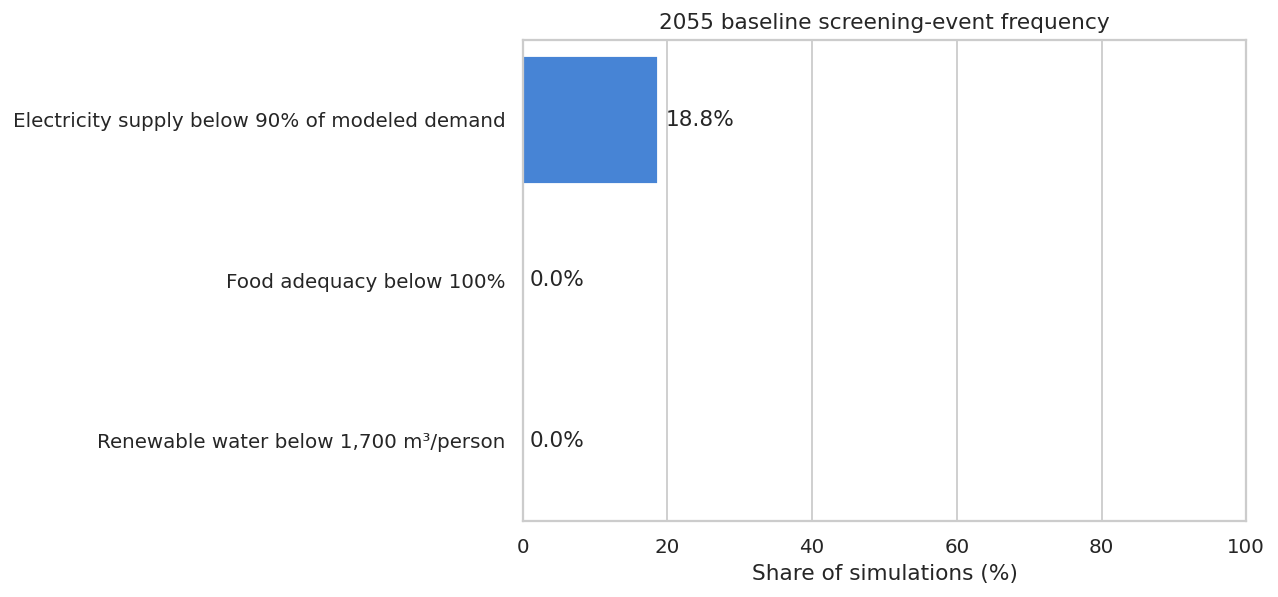

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=risk_probability, x="frequency_pct", y="screening_event", color=COLORS["blue"], ax=ax)
ax.set(xlim=(0, 100), xlabel="Share of simulations (%)", ylabel="", title="2055 baseline screening-event frequency")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "risk_probability.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Interpretation and responsible use

### What this analysis can support

- Comparing transparent population and resource scenarios
- Identifying which assumptions drive future pressure
- Demonstrating API collection, data validation, time-series backtesting, scenario analysis, and uncertainty simulation
- Generating questions for deeper regional or sector-specific research

### What it cannot prove

- The exact year the Philippines will “run out” of a resource
- Local water security, because national renewable-water averages hide geography, seasonality, storage, quality, and distribution
- Household food security, because national dietary energy adequacy does not measure affordability or equal access
- Grid reliability, because annual generation does not capture reserve margins, transmission congestion, outages, or hourly peaks
- Causal effects of a single policy

The best next version would add regional PSA population projections, Philippine DOE dependable capacity and peak-demand tables, PAGASA climate series, crop-level supply-utilization accounts, and probabilistic policy scenarios.

In [13]:
baseline_row = scenario_outlook.loc[scenario_outlook["scenario"].eq("Baseline")].iloc[0]
summary_payload = {
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "forecast_end": FORECAST_END,
    "population_source_for_scenarios": "UN World Population Prospects 2024 medium variant",
    "population_2055_millions": round(float(baseline_row.population_2055_millions), 3),
    "psa_scenario_2_2055_millions": psa_2055_millions,
    "baseline": {
        "electricity_coverage_2055_pct": round(float(baseline_row.electricity_coverage_2055_pct), 2),
        "first_electricity_below_90_year": baseline_row.first_electricity_below_90_year,
        "food_adequacy_2055_pct": round(float(baseline_row.food_adequacy_2055_pct), 2),
        "first_food_below_100_year": baseline_row.first_food_below_100_year,
        "renewable_water_2055_m3_per_person": round(float(baseline_row.renewable_water_2055_m3_per_person), 2),
        "first_water_below_1700_year": baseline_row.first_water_below_1700_year,
    },
    "selected_models": {
        "population_comparison": population_best,
        "electricity_generation": generation_best,
        "electricity_demand_per_capita": electricity_pc_best,
        "food_adequacy": food_best,
    },
    "disclaimer": "Scenario-based portfolio analysis; not an official forecast or collapse prediction.",
}

(OUTPUT_DIR / "forecast_summary.json").write_text(
    json.dumps(summary_payload, indent=2), encoding="utf-8"
)

print("Baseline 2055 summary")
print(json.dumps(summary_payload["baseline"], indent=2))
print("\nGenerated files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")

Baseline 2055 summary
{
  "electricity_coverage_2055_pct": 96.14,
  "first_electricity_below_90_year": ">2055",
  "food_adequacy_2055_pct": 136.56,
  "first_food_below_100_year": ">2055",
  "renewable_water_2055_m3_per_person": 3544.5,
  "first_water_below_1700_year": ">2055"
}

Generated files:
- outputs/forecast_long.csv
- outputs/forecast_summary.json
- outputs/model_validation.csv
- outputs/monte_carlo_risk.csv
- outputs/population_forecast.png
- outputs/resource_scenarios.png
- outputs/risk_probability.png
- outputs/scenario_outlook.csv
- outputs/source_manifest.csv


## Official and methodological references

- [UN World Population Prospects 2024](https://population.un.org/wpp/)
- [Philippine Statistics Authority population projections](https://psa.gov.ph/statistics/census/projected-population)
- [World Bank Indicators API](https://datahelpdesk.worldbank.org/knowledgebase/articles/889392)
- [FAOSTAT](https://www.fao.org/faostat/en/)
- [FAO AQUASTAT Philippines](https://www.fao.org/aquastat/en/countries-and-basins/country-profiles/country/PHL/index.html)
- [Philippine Department of Energy power statistics](https://doe.gov.ph/site/epimb/articles/group/statistics?category=Philippine%20Power%20Statistics&display_type=Card)
- [Our World in Data energy dataset](https://github.com/owid/energy-data)

Data licenses and terms remain with their respective publishers. Review them before redistributing raw source files.